Full-superstructure OCFE Pyomo model built.


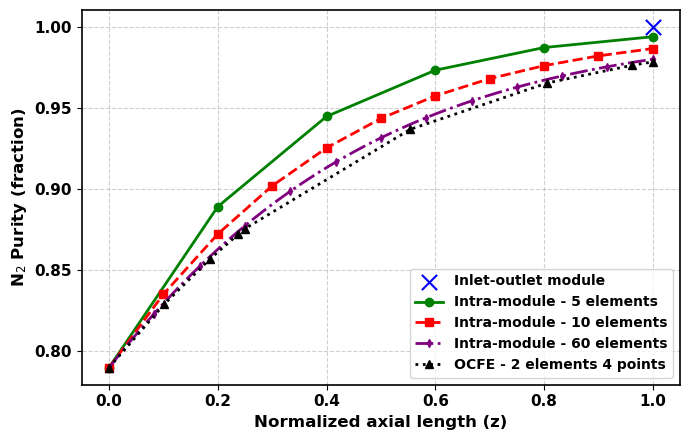

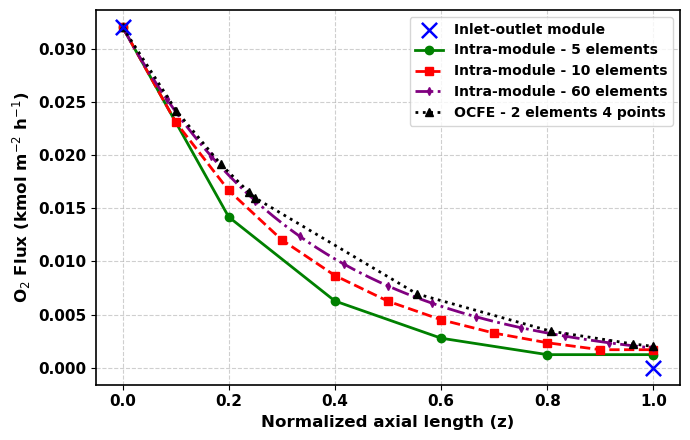

In [10]:
from pyomo.environ import *
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root

def lagrange_weights(node_positions, eval_position):
    n = len(node_positions)
    W = []
    for j in range(n):
        num = 1.0
        den = 1.0
        for k in range(n):
            if k == j:
                continue
            num *= (eval_position - node_positions[k])
            den *= (node_positions[j] - node_positions[k])
        W.append(num / den)
    return W


def build_model():
    model = ConcreteModel()

    # SETS
    model.I = Set(initialize=["O2", "N2"])      # species
    model.M = Set(initialize=[1, 2])            # candidate membrane modules
    model.NR = Set(initialize=["feed"])         # feed streams to retentate side
    model.NS = Set(initialize=["sweep"])        # sweep streams to permeate side
    model.PR = Set(initialize=["N2_prod"])      # retentate products
    model.PS = Set(initialize=["perm_prod"])    # permeate products

    # OCFE sets
    model.L = Set(initialize=[1, 2])            # finite elements
    model.J = RangeSet(0, 4)                    # collocation nodes
    model.Jc = RangeSet(0, 3)                   # evaluation nodes


    # PARAMETERS
    F_feed_total = 2280.75
    FI_NR_data = {
        ("O2", "feed"): 0.21 * F_feed_total,
        ("N2", "feed"): 0.79 * F_feed_total,
    }

    # no sweep gas for this example
    FI_NS_data = {
        ("O2", "sweep"): 1e-8,
        ("N2", "sweep"): 1e-8,
    }

    Pi_data = {
        "O2": 1600 * 1.20564e-9,
        "N2": 160 * 1.20564e-9,
    }

    RecoveryMin = 0.9656
    PurityMin = 0.9979

    CA = 20.0
    alpha = 688.2
    V_module = 20.0
    Amax = 50000.0
    Fmax = 1e5

    # Feed and membrane parameters (some may be repititive but keep both)
    F_total = 2300  # kmol/h
    F_feed = {'O2': 0.21 * F_total, 'N2': 0.79 * F_total}
    perm = {'O2': 1600 * 1.20564e-9, 'N2': 160 * 1.20564e-9}
    alpha = 688.2
    ModuleVolume = 20.0
    A_total = 42000.0
    species = ['O2', 'N2']

    F_N2_feed = F_feed['N2']
    F_O2_feed = F_feed['O2']

    model.FI_NR = Param(model.I, model.NR, initialize=FI_NR_data)
    model.FI_NS = Param(model.I, model.NS, initialize=FI_NS_data)
    model.Pi = Param(model.I, initialize=Pi_data)
    model.CA = Param(initialize=CA)
    model.alpha = Param(initialize=alpha)
    model.V_module = Param(initialize=V_module)
    model.Amax = Param(initialize=Amax)
    model.Fmax = Param(initialize=Fmax)
    model.RecoveryMin = Param(initialize=RecoveryMin)
    model.PurityMin = Param(initialize=PurityMin)

    # element lengths
    L_elem_data = {
        (1, 1): 0.05062,
        (1, 2): 0.145 - 0.05062,
        (2, 1): 0.05062,
        (2, 2): 0.145 - 0.05062,
    }
    model.L_elem = Param(model.M, model.L, initialize=L_elem_data, mutable=True)

    def V_elem_init(mod, m, l):
        total_length = sum(value(mod.L_elem[m, ll]) for ll in mod.L)
        return value(mod.V_module) * value(mod.L_elem[m, l]) / total_length

    model.V_elem = Param(model.M, model.L, initialize=V_elem_init, mutable=True)

    # collocation points in [0,1]
    s_rel = {0: 0.0, 1: 0.40585, 2: 0.74153, 3: 0.94911, 4: 1.0}

    # area fraction per element
    def area_frac_rule(mod, m, l):
        return value(mod.L_elem[m, l]) / sum(value(mod.L_elem[m, ll]) for ll in mod.L)

    model.area_frac = Param(model.M, model.L, initialize=area_frac_rule)


    # DECISION VARIABLES
    # module activation
    model.y = Var(model.M, within=Binary)

    # stream existence binaries
    model.z_IR = Var(model.NR, model.M, within=Binary)
    model.z_IS = Var(model.NS, model.M, within=Binary)
    model.z_RR = Var(model.M, model.M, within=Binary)
    model.z_SS = Var(model.M, model.M, within=Binary)
    model.z_RP = Var(model.M, model.PR, within=Binary)
    model.z_SP = Var(model.M, model.PS, within=Binary)

    # module area
    model.A = Var(model.M, within=NonNegativeReals)

    # interconnection flows from overall superstructure
    model.F_IR = Var(model.I, model.NR, model.M, within=NonNegativeReals)
    model.F_IS = Var(model.I, model.NS, model.M, within=NonNegativeReals)
    model.F_RR = Var(model.I, model.M, model.M, within=NonNegativeReals)
    model.F_SS = Var(model.I, model.M, model.M, within=NonNegativeReals)
    model.F_RP = Var(model.I, model.M, model.PR, within=NonNegativeReals)
    model.F_SP = Var(model.I, model.M, model.PS, within=NonNegativeReals)

    # product flow variables
    model.FP_R = Var(model.I, model.PR, within=NonNegativeReals)
    model.FP_S = Var(model.I, model.PS, within=NonNegativeReals)

    # module inlet totals from superstructure
    model.F_RI0 = Var(model.I, model.M, within=NonNegativeReals)
    model.F_SI0 = Var(model.I, model.M, within=NonNegativeReals)

    # OCFE state variables
    model.F_RI = Var(model.I, model.M, model.L, model.J, within=NonNegativeReals)
    model.F_SI = Var(model.I, model.M, model.L, model.J, within=NonNegativeReals)

    model.FT_RI = Var(model.M, model.L, model.J, within=NonNegativeReals)
    model.FT_SI = Var(model.M, model.L, model.J, within=NonNegativeReals)

    model.F_RO = Var(model.I, model.M, model.L, model.Jc, within=NonNegativeReals)
    model.F_SO = Var(model.I, model.M, model.L, model.Jc, within=NonNegativeReals)

    model.p_RI = Var(model.I, model.M, model.L, model.J)
    model.p_SI = Var(model.I, model.M, model.L, model.J)

    model.Jflux = Var(model.I, model.M, model.L, model.J, within=NonNegativeReals)

    # module outlet streams used by superstructure
    model.F_RO_out = Var(model.I, model.M, within=NonNegativeReals)
    model.F_SO_out = Var(model.I, model.M, within=NonNegativeReals)

    # EXPRESSIONS
    def A_elem_rule(mod, m, l):
        return mod.A[m] * mod.area_frac[m, l]

    model.A_elem = Expression(model.M, model.L, rule=A_elem_rule)

    # interpolation weights
    W_data = {}
    for m in model.M:
        for l in model.L:
            Lval = value(model.L_elem[m, l])
            node_positions = [s_rel[j] * Lval for j in range(5)]
            eval_positions = [node_positions[j] for j in range(4)]
            for jc, s_eval in enumerate(eval_positions):
                w_list = lagrange_weights(node_positions, s_eval)
                for j, w in enumerate(w_list):
                    W_data[(m, l, jc, j)] = float(w)

    def W_init(mod, m, l, jc, j):
        return W_data[(m, l, jc, j)]

    model.W = Param(model.M, model.L, model.Jc, model.J, initialize=W_init)

    # SUPERSTRUCTURE MASS BALANCES
    def feed_split_rule(mod, i, nr):
        return mod.FI_NR[i, nr] == sum(mod.F_IR[i, nr, m] for m in mod.M)
    model.feed_split_con = Constraint(model.I, model.NR, rule=feed_split_rule)

    def sweep_split_rule(mod, i, ns):
        return mod.FI_NS[i, ns] == sum(mod.F_IS[i, ns, m] for m in mod.M)
    model.sweep_split_con = Constraint(model.I, model.NS, rule=sweep_split_rule)

    def retentate_mixer_rule(mod, i, m):
        return mod.F_RI0[i, m] == (
            sum(mod.F_IR[i, nr, m] for nr in mod.NR)
            + sum(mod.F_RR[i, mp, m] for mp in mod.M if mp != m)
        )
    model.retentate_mixer = Constraint(model.I, model.M, rule=retentate_mixer_rule)

    def permeate_mixer_rule(mod, i, m):
        return mod.F_SI0[i, m] == (
            sum(mod.F_IS[i, ns, m] for ns in mod.NS)
            + sum(mod.F_SS[i, mp, m] for mp in mod.M if mp != m)
        )
    model.permeate_mixer = Constraint(model.I, model.M, rule=permeate_mixer_rule)

    def retentate_splitter_rule(mod, i, m):
        return mod.F_RO_out[i, m] == (
            sum(mod.F_RR[i, m, mp] for mp in mod.M if mp != m)
            + sum(mod.F_RP[i, m, pr] for pr in mod.PR)
        )
    model.retentate_splitter = Constraint(model.I, model.M, rule=retentate_splitter_rule)

    def permeate_splitter_rule(mod, i, m):
        return mod.F_SO_out[i, m] == (
            sum(mod.F_SS[i, m, mp] for mp in mod.M if mp != m)
            + sum(mod.F_SP[i, m, ps] for ps in mod.PS)
        )
    model.permeate_splitter = Constraint(model.I, model.M, rule=permeate_splitter_rule)

    def final_retentate_product_rule(mod, i, pr):
        return mod.FP_R[i, pr] == sum(mod.F_RP[i, m, pr] for m in mod.M)
    model.final_retentate_product = Constraint(model.I, model.PR, rule=final_retentate_product_rule)

    def final_permeate_product_rule(mod, i, ps):
        return mod.FP_S[i, ps] == sum(mod.F_SP[i, m, ps] for m in mod.M)
    model.final_permeate_product = Constraint(model.I, model.PS, rule=final_permeate_product_rule)


    # BIG-M CONSTRAINTS
    def bigM_IR_rule(mod, i, nr, m):
        return mod.F_IR[i, nr, m] <= mod.Fmax * mod.z_IR[nr, m]
    model.bigM_IR = Constraint(model.I, model.NR, model.M, rule=bigM_IR_rule)

    def bigM_IS_rule(mod, i, ns, m):
        return mod.F_IS[i, ns, m] <= mod.Fmax * mod.z_IS[ns, m]
    model.bigM_IS = Constraint(model.I, model.NS, model.M, rule=bigM_IS_rule)

    def bigM_RR_rule(mod, i, m, mp):
        if m == mp:
            return Constraint.Skip
        return mod.F_RR[i, m, mp] <= mod.Fmax * mod.z_RR[m, mp]
    model.bigM_RR = Constraint(model.I, model.M, model.M, rule=bigM_RR_rule)

    def bigM_SS_rule(mod, i, m, mp):
        if m == mp:
            return Constraint.Skip
        return mod.F_SS[i, m, mp] <= mod.Fmax * mod.z_SS[m, mp]
    model.bigM_SS = Constraint(model.I, model.M, model.M, rule=bigM_SS_rule)

    def bigM_RP_rule(mod, i, m, pr):
        return mod.F_RP[i, m, pr] <= mod.Fmax * mod.z_RP[m, pr]
    model.bigM_RP = Constraint(model.I, model.M, model.PR, rule=bigM_RP_rule)

    def bigM_SP_rule(mod, i, m, ps):
        return mod.F_SP[i, m, ps] <= mod.Fmax * mod.z_SP[m, ps]
    model.bigM_SP = Constraint(model.I, model.M, model.PS, rule=bigM_SP_rule)

    # MODULE ACTIVATION CONSTRAINTS
    def act_RR_rule(mod, m, mp):
        if m == mp:
            return Constraint.Skip
        return mod.z_RR[m, mp] <= mod.y[m]
    model.act_RR = Constraint(model.M, model.M, rule=act_RR_rule)

    def act_SS_rule(mod, m, mp):
        if m == mp:
            return Constraint.Skip
        return mod.z_SS[m, mp] <= mod.y[m]
    model.act_SS = Constraint(model.M, model.M, rule=act_SS_rule)

    def act_RP_rule(mod, m, pr):
        return mod.z_RP[m, pr] <= mod.y[m]
    model.act_RP = Constraint(model.M, model.PR, rule=act_RP_rule)

    def act_SP_rule(mod, m, ps):
        return mod.z_SP[m, ps] <= mod.y[m]
    model.act_SP = Constraint(model.M, model.PS, rule=act_SP_rule)

    def act_IR_rule(mod, nr, m):
        return mod.z_IR[nr, m] <= mod.y[m]
    model.act_IR = Constraint(model.NR, model.M, rule=act_IR_rule)

    def act_IS_rule(mod, ns, m):
        return mod.z_IS[ns, m] <= mod.y[m]
    model.act_IS = Constraint(model.NS, model.M, rule=act_IS_rule)

    def area_activation_rule(mod, m):
        return mod.A[m] <= mod.Amax * mod.y[m]
    model.area_activation = Constraint(model.M, rule=area_activation_rule)

    def module_has_exit_rule(mod, m):
        return (
            sum(mod.z_RR[m, mp] for mp in mod.M if mp != m)
            + sum(mod.z_RP[m, pr] for pr in mod.PR)
            >= mod.y[m]
        )
    model.module_has_exit = Constraint(model.M, rule=module_has_exit_rule)

    # LINK SUPERSTRUCTURE TO OCFE MODULE INLETS
    def RI0_to_ocfe_rule(mod, i, m):
        return mod.F_RI[i, m, 1, 0] == mod.F_RI0[i, m]
    model.RI0_to_ocfe = Constraint(model.I, model.M, rule=RI0_to_ocfe_rule)

    def SI0_to_ocfe_rule(mod, i, m):
        return mod.F_SI[i, m, 1, 0] == mod.F_SI0[i, m]
    model.SI0_to_ocfe = Constraint(model.I, model.M, rule=SI0_to_ocfe_rule)

    # OCFE TOTAL FLOWS
    def total_RI_rule(mod, m, l, j):
        return sum(mod.F_RI[i, m, l, j] for i in mod.I) == mod.FT_RI[m, l, j]
    model.total_RI = Constraint(model.M, model.L, model.J, rule=total_RI_rule)

    def total_SI_rule(mod, m, l, j):
        return sum(mod.F_SI[i, m, l, j] for i in mod.I) == mod.FT_SI[m, l, j]
    model.total_SI = Constraint(model.M, model.L, model.J, rule=total_SI_rule)

    # PARTIAL PRESSURES
    def p_RI_rule(mod, i, m, l, j):
        return mod.p_RI[i, m, l, j] == mod.alpha * mod.F_RI[i, m, l, j] / mod.V_elem[m, l]
    model.p_RI_def = Constraint(model.I, model.M, model.L, model.J, rule=p_RI_rule)

    def p_SI_rule(mod, i, m, l, j):
        return mod.p_SI[i, m, l, j] == mod.alpha * mod.F_SI[i, m, l, j] / mod.V_elem[m, l]
    model.p_SI_def = Constraint(model.I, model.M, model.L, model.J, rule=p_SI_rule)


    # OCFE INTERPOLATION
    def F_RO_interp_rule(mod, i, m, l, jc):
        return sum(mod.W[m, l, jc, j] * mod.F_RI[i, m, l, j] for j in mod.J) == mod.F_RO[i, m, l, jc]
    model.F_RO_interp = Constraint(model.I, model.M, model.L, model.Jc, rule=F_RO_interp_rule)

    def F_SO_interp_rule(mod, i, m, l, jc):
        return sum(mod.W[m, l, jc, j] * mod.F_SI[i, m, l, j] for j in mod.J) == mod.F_SO[i, m, l, jc]
    model.F_SO_interp = Constraint(model.I, model.M, model.L, model.Jc, rule=F_SO_interp_rule)


    # LOCAL FLUX LAW
    def flux_rule(mod, i, m, l, j):
        node_area = mod.A_elem[m, l] / (len(list(mod.J)) - 1)
        return mod.Jflux[i, m, l, j] == mod.Pi[i] * (mod.p_RI[i, m, l, j] - mod.p_SI[i, m, l, j]) * node_area
    model.flux_def = Constraint(model.I, model.M, model.L, model.J, rule=flux_rule)

    # OCFE MASS BALANCES
    def mass_balance_R_rule(mod, i, m, l, j):
        if j == 4:
            return Constraint.Skip
        jc = j
        delta = value(mod.L_elem[m, l]) / (len(list(mod.J)) - 1)
        return mod.F_RI[i, m, l, j] - mod.F_RO[i, m, l, jc] - mod.Jflux[i, m, l, j] * delta == 0
    model.mass_balance_R = Constraint(model.I, model.M, model.L, model.J, rule=mass_balance_R_rule)

    def mass_balance_S_rule(mod, i, m, l, j):
        if j == 4:
            return Constraint.Skip
        jc = j
        delta = value(mod.L_elem[m, l]) / (len(list(mod.J)) - 1)
        return mod.F_SI[i, m, l, j] - mod.F_SO[i, m, l, jc] + mod.Jflux[i, m, l, j] * delta == 0
    model.mass_balance_S = Constraint(model.I, model.M, model.L, model.J, rule=mass_balance_S_rule)

    # CONTINUITY BETWEEN FINITE ELEMENTS
    def continuity_R_rule(mod, i, m, l):
        if l == 1:
            return Constraint.Skip
        return mod.F_RO[i, m, l - 1, 3] == mod.F_RI[i, m, l, 0]
    model.continuity_R = Constraint(model.I, model.M, model.L, rule=continuity_R_rule)

    def continuity_S_rule(mod, i, m, l):
        if l == 1:
            return Constraint.Skip
        return mod.F_SO[i, m, l - 1, 3] == mod.F_SI[i, m, l, 0]
    model.continuity_S = Constraint(model.I, model.M, model.L, rule=continuity_S_rule)

    # MODULE OUTLET DEFINITIONS
    def RO_out_rule(mod, i, m):
        last_l = max(list(mod.L))
        return mod.F_RO_out[i, m] == mod.F_RO[i, m, last_l, 3]
    model.RO_out_def = Constraint(model.I, model.M, rule=RO_out_rule)

    def SO_out_rule(mod, i, m):
        last_l = max(list(mod.L))
        return mod.F_SO_out[i, m] == mod.F_SO[i, m, last_l, 3]
    model.SO_out_def = Constraint(model.I, model.M, rule=SO_out_rule)

    # PRODUCT SPECS
    def N2_recovery_rule(mod):
        pr = "N2_prod"
        return mod.FP_R["N2", pr] >= mod.RecoveryMin * mod.FI_NR["N2", "feed"]
    model.N2_recovery = Constraint(rule=N2_recovery_rule)

    def N2_purity_rule(mod):
        pr = "N2_prod"
        return mod.FP_R["N2", pr] >= mod.PurityMin * sum(mod.FP_R[i, pr] for i in mod.I)
    model.N2_purity = Constraint(rule=N2_purity_rule)

    # OBJECTIVE
    model.obj = Objective(
        expr=model.CA * sum(model.A[m] for m in model.M),
        sense=minimize
    )

    # INITIALIZATION
    for m in model.M:
        model.y[m].value = 1
        model.A[m].value = 15000.0

        for nr in model.NR:
            model.z_IR[nr, m].value = 1
        for ns in model.NS:
            model.z_IS[ns, m].value = 0
        for pr in model.PR:
            model.z_RP[m, pr].value = 1
        for ps in model.PS:
            model.z_SP[m, ps].value = 0

        for mp in model.M:
            model.z_RR[m, mp].value = 0
            model.z_SS[m, mp].value = 0

    for i in model.I:
        for nr in model.NR:
            for m in model.M:
                model.F_IR[i, nr, m].value = value(model.FI_NR[i, nr]) / len(list(model.M))

        for ns in model.NS:
            for m in model.M:
                model.F_IS[i, ns, m].value = value(model.FI_NS[i, ns])

        for m in model.M:
            model.F_RI0[i, m].value = value(model.FI_NR[i, "feed"]) / len(list(model.M))
            model.F_SI0[i, m].value = 1e-8
            model.F_RO_out[i, m].value = value(model.FI_NR[i, "feed"]) / len(list(model.M))
            model.F_SO_out[i, m].value = 1e-8

            for pr in model.PR:
                model.F_RP[i, m, pr].value = value(model.FI_NR[i, "feed"]) / len(list(model.M))
            for ps in model.PS:
                model.F_SP[i, m, ps].value = 0.0
            for mp in model.M:
                model.F_RR[i, m, mp].value = 0.0
                model.F_SS[i, m, mp].value = 0.0

            for l in model.L:
                for j in model.J:
                    model.F_RI[i, m, l, j].value = value(model.FI_NR[i, "feed"]) / (
                        len(list(model.M)) * len(list(model.L)) * len(list(model.J))
                    )
                    model.F_SI[i, m, l, j].value = 1e-8
                    model.Jflux[i, m, l, j].value = 0.0

                for jc in model.Jc:
                    model.F_RO[i, m, l, jc].value = value(model.FI_NR[i, "feed"]) / len(list(model.M))
                    model.F_SO[i, m, l, jc].value = 1e-8

    for i in model.I:
        for pr in model.PR:
            model.FP_R[i, pr].value = value(model.FI_NR[i, "feed"])
        for ps in model.PS:
            model.FP_S[i, ps].value = 0.0

    return model


if __name__ == "__main__":
    m = build_model()
    print("Full-superstructure OCFE Pyomo model built.")


# Module-in-series model
def simulate_series(num_modules, F_in, species):
    A_module = A_total / num_modules
    z_list = [0.0]
    F_R_records = {sp: [F_in[sp]] for sp in species}
    F_R = F_in.copy()

    for k in range(num_modules):
        p = {sp: alpha * F_R[sp] / ModuleVolume for sp in species}
        J = {sp: perm[sp] * p[sp] * A_module for sp in species}

        for sp in species:
            F_R[sp] = max(0.0, F_R[sp] - J[sp])

        z_list.append((k + 1) / num_modules)
        for sp in species:
            F_R_records[sp].append(F_R[sp])

    z = np.array(z_list)
    profiles = {sp: np.array(F_R_records[sp]) for sp in species}
    return z, profiles

# Lumped single-module model
def simulate_lumped_single_module(F_in, species):
    p = {sp: alpha * F_in[sp] / ModuleVolume for sp in species}
    J = {sp: perm[sp] * p[sp] * A_total for sp in species}

    F_out = {}
    for sp in species:
        F_out[sp] = max(0.0, F_in[sp] - J[sp])

    z = np.array([0.0, 1.0])
    profiles = {sp: np.array([F_in[sp], F_out[sp]]) for sp in species}
    return z, profiles

# Lagrange derivative matrix
def lagrange_derivative_matrix(nodes):
    nodes = np.asarray(nodes, dtype=float)
    n = len(nodes)

    w = np.ones(n, dtype=float)
    for j in range(n):
        for k in range(n):
            if k != j:
                w[j] /= (nodes[j] - nodes[k])

    D = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(n):
            if i != j:
                D[i, j] = w[j] / (w[i] * (nodes[i] - nodes[j]))

    for i in range(n):
        D[i, i] = -np.sum(D[i, :])
    return D
    
def simulate_ocfe_true(F_in, species, num_elements=2, points_per_element=4):

    if num_elements == 2:
        element_lengths = np.array([0.25, 0.75], dtype=float)
    else:
        element_lengths = np.ones(num_elements) / num_elements

    total_length = np.sum(element_lengths)

    local_nodes = np.array([0.0, 0.40585, 0.74153, 0.94911, 1.0], dtype=float)
    D = lagrange_derivative_matrix(local_nodes)

    h = element_lengths / total_length
    n_elem = len(element_lengths)
    n_nodes = len(local_nodes)

    # Global z coordinates
    z_list = []
    x_offset = 0.0
    for e, Le in enumerate(element_lengths):
        x_elem = x_offset + Le * local_nodes
        z_elem = x_elem / total_length
        if e == 0:
            z_list.extend(z_elem.tolist())
        else:
            z_list.extend(z_elem[1:].tolist())
        x_offset += Le
    z = np.array(z_list)

    n_unknown_per_species = n_elem * (n_nodes - 1)

    def unpack_species_vector(x_sp, F0):
        elem_vals = []
        cursor = 0
        prev_end = F0

        for e in range(n_elem):
            y = np.zeros(n_nodes)
            y[0] = prev_end
            y[1:] = x_sp[cursor:cursor + (n_nodes - 1)]
            elem_vals.append(y)
            prev_end = y[-1]
            cursor += (n_nodes - 1)

        return elem_vals

    def residuals_all(x):
        res = []
        cursor = 0

        for sp in species:
            x_sp = x[cursor:cursor + n_unknown_per_species]
            cursor += n_unknown_per_species

            k_sp = A_total * alpha * perm[sp] / ModuleVolume
            elem_vals = unpack_species_vector(x_sp, F_in[sp])

            for e in range(n_elem):
                y = elem_vals[e]

                for j in range(1, n_nodes):
                    dy_dtau = np.dot(D[j, :], y)
                    dy_dz = dy_dtau / h[e]
                    residual = dy_dz + k_sp * y[j]
                    res.append(residual)

        return np.array(res)

    x0 = []
    for sp in species:
        k_sp = A_total * alpha * perm[sp] / ModuleVolume
        y_guess = F_in[sp] * np.exp(-k_sp * z)

        idx = 1
        for e in range(n_elem):
            for _ in range(n_nodes - 1):
                if idx < len(y_guess):
                    x0.append(y_guess[idx])
                    idx += 1
                else:
                    x0.append(F_in[sp])

    x0 = np.array(x0)

    sol = root(residuals_all, x0, method='hybr', options={'maxfev': 10000})

    if not sol.success:
        print(f"Warning: OCFE solver did not fully converge: {sol.message}")

    profiles = {}
    cursor = 0
    for sp in species:
        x_sp = sol.x[cursor:cursor + n_unknown_per_species]
        cursor += n_unknown_per_species

        elem_vals = unpack_species_vector(x_sp, F_in[sp])

        y_global = []
        for e, y in enumerate(elem_vals):
            if e == 0:
                y_global.extend(y.tolist())
            else:
                y_global.extend(y[1:].tolist())

        profiles[sp] = np.array(y_global)

    return z, profiles

def compute_recovery_purity(prof):
    N2 = prof['N2']
    O2 = prof['O2']
    recovery = N2 / F_N2_feed
    purity = N2 / (N2 + O2)
    return recovery, purity
    
def compute_local_flux_profile(prof, sp):
    return perm[sp] * alpha * prof[sp] / ModuleVolume

def compute_stage_average_flux_extended(num_modules, prof, sp):
    A_module = A_total / num_modules
    F_in_stage = prof[sp][:-1]
    F_out_stage = prof[sp][1:]
    J_stage_avg = (F_in_stage - F_out_stage) / A_module

    # Left boundaries: 0, 1/N, ..., (N-1)/N
    z_stage = np.arange(num_modules) / num_modules

    # Extend to z = 1 using the final stage-average value
    z_plot = np.append(z_stage, 1.0)
    J_plot = np.append(J_stage_avg, J_stage_avg[-1])

    return z_plot, J_plot

def compute_lumped_inlet_outlet_flux(prof, sp):
    F_in = prof[sp][0]
    F_out = prof[sp][1]

    J_in = perm[sp] * alpha * F_in / ModuleVolume
    J_out = perm[sp] * alpha * F_out / ModuleVolume

    z_points = np.array([0.0, 1.0])
    J_points = np.array([J_in, J_out])

    return z_points, J_points

# Lumped single module
z_lumped, prof_lumped = simulate_lumped_single_module(F_feed.copy(), species)
_, pur_lumped = compute_recovery_purity(prof_lumped)

# Staged models
z5, prof5 = simulate_series(5, F_feed.copy(), species)
z10, prof10 = simulate_series(10, F_feed.copy(), species)
z60, prof60 = simulate_series(60, F_feed.copy(), species)

# OCFE model
zocfe, profocfe = simulate_ocfe_true(F_feed.copy(), species)

# Purity calculations
_, pur5 = compute_recovery_purity(prof5)
_, pur10 = compute_recovery_purity(prof10)
_, pur60 = compute_recovery_purity(prof60)
_, purocfe = compute_recovery_purity(profocfe)

# Flux calculations for oxygen
z_lumped_flux, J_lumped_O2 = compute_lumped_inlet_outlet_flux(prof_lumped, 'O2')

# Series-model stage-average flux
z5_flux, J5_avg_O2 = compute_stage_average_flux_extended(5, prof5, 'O2')
z10_flux, J10_avg_O2 = compute_stage_average_flux_extended(10, prof10, 'O2')
z60_flux, J60_avg_O2 = compute_stage_average_flux_extended(60, prof60, 'O2')

# OCFE local flux
Jocfe_O2 = compute_local_flux_profile(profocfe, 'O2')

# ------------------------------
# Plot 1: N2 purity
# ------------------------------
fig2, ax2 = plt.subplots(figsize=(7, 4.5))

# Lumped model: outlet purity only
ax2.scatter(z_lumped[-1], pur_lumped[-1],
            color='blue', s=120, marker='x', linewidths=1.5, zorder=5,
            label='Inlet-outlet module')

# Staged models
ax2.plot(z5, pur5, '-o', linewidth=2, markersize=6,
         label='Intra-module - 5 elements', color='green')

ax2.plot(z10, pur10, '--s', linewidth=2, markersize=6,
         label='Intra-module - 10 elements', color='red')

ax2.plot(z60, pur60, '-.d', linewidth=2, markersize=4, markevery=5,
         label='Intra-module - 60 elements', color='purple')

# OCFE model
ax2.plot(zocfe, purocfe, ':^', linewidth=2, markersize=6,
         label='OCFE - 2 elements 4 points', color='black')

ax2.set_xlabel('Normalized axial length (z)', fontsize=12, fontweight='bold')
ax2.set_ylabel('N$_2$ Purity (fraction)', fontsize=12, fontweight='bold')

ax2.tick_params(axis='both', labelsize=11)
for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_fontweight('bold')

ax2.grid(True, linestyle='--', alpha=0.6)

legend = ax2.legend(fontsize=10, frameon=True, loc='best')
for text in legend.get_texts():
    text.set_fontweight('bold')

for spine in ax2.spines.values():
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

fig3, ax3 = plt.subplots(figsize=(7, 4.5))

# Lumped single module: inlet and outlet flux points
ax3.scatter(z_lumped_flux, J_lumped_O2,
            color='blue', s=120, marker='x', linewidths=1.8, zorder=5,
            label='Inlet-outlet module')

# Series models
ax3.plot(z5_flux, J5_avg_O2, '-o', linewidth=2, markersize=6,
         label='Intra-module - 5 elements', color='green')

ax3.plot(z10_flux, J10_avg_O2, '--s', linewidth=2, markersize=6,
         label='Intra-module - 10 elements', color='red')

ax3.plot(z60_flux, J60_avg_O2, '-.d', linewidth=2, markersize=4, markevery=5,
         label='Intra-module - 60 elements', color='purple')

# OCFE model: continuous local flux
ax3.plot(zocfe, Jocfe_O2, ':^', linewidth=2, markersize=6,
         label='OCFE - 2 elements 4 points', color='black')

ax3.set_xlabel('Normalized axial length (z)', fontsize=12, fontweight='bold')
ax3.set_ylabel('O$_2$ Flux (kmol m$^{-2}$ h$^{-1}$)', fontsize=12, fontweight='bold')

ax3.tick_params(axis='both', labelsize=11)
for label in ax3.get_xticklabels() + ax3.get_yticklabels():
    label.set_fontweight('bold')

ax3.grid(True, linestyle='--', alpha=0.6)

legend = ax3.legend(fontsize=10, frameon=True, loc='best')
for text in legend.get_texts():
    text.set_fontweight('bold')

for spine in ax3.spines.values():
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

In [13]:
from pyomo.environ import *
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root

def lagrange_weights(node_positions, eval_position):
    n = len(node_positions)
    W = []
    for j in range(n):
        num = 1.0
        den = 1.0
        for k in range(n):
            if k == j:
                continue
            num *= (eval_position - node_positions[k])
            den *= (node_positions[j] - node_positions[k])
        W.append(num / den)
    return W


def build_model(n_modules=4):
    model = ConcreteModel()

    # SETS
    model.I = Set(initialize=["O2", "N2"])      # species
    model.M = Set(initialize=range(1, n_modules+1))            # candidate membrane modules
    model.NR = Set(initialize=["feed"])         # feed streams to retentate side
    model.NS = Set(initialize=["sweep"])        # sweep streams to permeate side
    model.PR = Set(initialize=["N2_prod"])      # retentate products
    model.PS = Set(initialize=["perm_prod"])    # permeate products

    # OCFE sets
    model.L = Set(initialize=[1, 2])            # finite elements
    model.J = RangeSet(0, 4)                    # collocation nodes
    model.Jc = RangeSet(0, 3)                   # evaluation nodes


    # PARAMETERS
    F_feed_total = 2280.75
    FI_NR_data = {
        ("O2", "feed"): 0.21 * F_feed_total,
        ("N2", "feed"): 0.79 * F_feed_total,
    }

    # no sweep gas for this example
    FI_NS_data = {
        ("O2", "sweep"): 1e-8,
        ("N2", "sweep"): 1e-8,
    }

    Pi_data = {
        "O2": 1600 * 1.20564e-9,
        "N2": 160 * 1.20564e-9,
    }

    RecoveryMin = 0.9656
    PurityMin = 0.9979

    CA = 20.0
    alpha = 688.2
    V_module = 20.0
    Amax = 50000.0
    Fmax = 1e5

    # Feed and membrane parameters (some may be repititive but keep both)
    F_total = 2300  # kmol/h
    F_feed = {'O2': 0.21 * F_total, 'N2': 0.79 * F_total}
    perm = {'O2': 1600 * 1.20564e-9, 'N2': 160 * 1.20564e-9}
    alpha = 688.2
    ModuleVolume = 20.0
    A_total = 42000.0
    species = ['O2', 'N2']

    F_N2_feed = F_feed['N2']
    F_O2_feed = F_feed['O2']

    # Feed and membrane parameters (some may be repititive but keep both)
    F_total = 2300  # kmol/h
    F_feed = {'O2': 0.21 * F_total, 'N2': 0.79 * F_total}
    perm = {'O2': 1600 * 1.20564e-9, 'N2': 160 * 1.20564e-9}
    alpha = 688.2
    ModuleVolume = 20.0
    A_total = 42000.0
    species = ['O2', 'N2']

    F_N2_feed = F_feed['N2']
    F_O2_feed = F_feed['O2']

    model.FI_NR = Param(model.I, model.NR, initialize=FI_NR_data)
    model.FI_NS = Param(model.I, model.NS, initialize=FI_NS_data)
    model.Pi = Param(model.I, initialize=Pi_data)
    model.CA = Param(initialize=CA)
    model.alpha = Param(initialize=alpha)
    model.V_module = Param(initialize=V_module)
    model.Amax = Param(initialize=Amax)
    model.Fmax = Param(initialize=Fmax)
    model.RecoveryMin = Param(initialize=RecoveryMin)
    model.PurityMin = Param(initialize=PurityMin)

    # element lengths
    L_elem_data = {}
    for m in model.M:
        L_elem_data[(m, 1)] = 0.05062
        L_elem_data[(m, 2)] = 0.145 - 0.05062  # = 0.09438

    model.L_elem = Param(model.M, model.L, initialize=L_elem_data, mutable=True)

    def V_elem_init(mod, m, l):
        total_length = sum(value(mod.L_elem[m, ll]) for ll in mod.L)
        return value(mod.V_module) * value(mod.L_elem[m, l]) / total_length

    model.V_elem = Param(model.M, model.L, initialize=V_elem_init, mutable=True)

    # collocation points in [0,1]
    s_rel = {0: 0.0, 1: 0.40585, 2: 0.74153, 3: 0.94911, 4: 1.0}

    # area fraction per element
    def area_frac_rule(mod, m, l):
        return value(mod.L_elem[m, l]) / sum(value(mod.L_elem[m, ll]) for ll in mod.L)

    model.area_frac = Param(model.M, model.L, initialize=area_frac_rule)


    # DECISION VARIABLES
    # module activation
    model.y = Var(model.M, within=Binary)

    # stream existence binaries
    model.z_IR = Var(model.NR, model.M, within=Binary)
    model.z_IS = Var(model.NS, model.M, within=Binary)
    model.z_RR = Var(model.M, model.M, within=Binary)
    model.z_SS = Var(model.M, model.M, within=Binary)
    model.z_RP = Var(model.M, model.PR, within=Binary)
    model.z_SP = Var(model.M, model.PS, within=Binary)

    # module area
    model.A = Var(model.M, within=NonNegativeReals)

    # interconnection flows from overall superstructure
    model.F_IR = Var(model.I, model.NR, model.M, within=NonNegativeReals)
    model.F_IS = Var(model.I, model.NS, model.M, within=NonNegativeReals)
    model.F_RR = Var(model.I, model.M, model.M, within=NonNegativeReals)
    model.F_SS = Var(model.I, model.M, model.M, within=NonNegativeReals)
    model.F_RP = Var(model.I, model.M, model.PR, within=NonNegativeReals)
    model.F_SP = Var(model.I, model.M, model.PS, within=NonNegativeReals)

    # product flow variables
    model.FP_R = Var(model.I, model.PR, within=NonNegativeReals)
    model.FP_S = Var(model.I, model.PS, within=NonNegativeReals)

    # module inlet totals from superstructure
    model.F_RI0 = Var(model.I, model.M, within=NonNegativeReals)
    model.F_SI0 = Var(model.I, model.M, within=NonNegativeReals)

    # OCFE state variables
    model.F_RI = Var(model.I, model.M, model.L, model.J, within=NonNegativeReals)
    model.F_SI = Var(model.I, model.M, model.L, model.J, within=NonNegativeReals)

    model.FT_RI = Var(model.M, model.L, model.J, within=NonNegativeReals)
    model.FT_SI = Var(model.M, model.L, model.J, within=NonNegativeReals)

    model.F_RO = Var(model.I, model.M, model.L, model.Jc, within=NonNegativeReals)
    model.F_SO = Var(model.I, model.M, model.L, model.Jc, within=NonNegativeReals)

    model.p_RI = Var(model.I, model.M, model.L, model.J)
    model.p_SI = Var(model.I, model.M, model.L, model.J)

    model.Jflux = Var(model.I, model.M, model.L, model.J, within=NonNegativeReals)

    # module outlet streams used by superstructure
    model.F_RO_out = Var(model.I, model.M, within=NonNegativeReals)
    model.F_SO_out = Var(model.I, model.M, within=NonNegativeReals)

    # EXPRESSIONS
    def A_elem_rule(mod, m, l):
        return mod.A[m] * mod.area_frac[m, l]

    model.A_elem = Expression(model.M, model.L, rule=A_elem_rule)

    # interpolation weights
    W_data = {}
    for m in model.M:
        for l in model.L:
            Lval = value(model.L_elem[m, l])
            node_positions = [s_rel[j] * Lval for j in range(5)]
            eval_positions = [node_positions[j] for j in range(4)]
            for jc, s_eval in enumerate(eval_positions):
                w_list = lagrange_weights(node_positions, s_eval)
                for j, w in enumerate(w_list):
                    W_data[(m, l, jc, j)] = float(w)

    def W_init(mod, m, l, jc, j):
        return W_data[(m, l, jc, j)]

    model.W = Param(model.M, model.L, model.Jc, model.J, initialize=W_init)

    # SUPERSTRUCTURE MASS BALANCES
    def feed_split_rule(mod, i, nr):
        return mod.FI_NR[i, nr] == sum(mod.F_IR[i, nr, m] for m in mod.M)
    model.feed_split_con = Constraint(model.I, model.NR, rule=feed_split_rule)

    def sweep_split_rule(mod, i, ns):
        return mod.FI_NS[i, ns] == sum(mod.F_IS[i, ns, m] for m in mod.M)
    model.sweep_split_con = Constraint(model.I, model.NS, rule=sweep_split_rule)

    def retentate_mixer_rule(mod, i, m):
        return mod.F_RI0[i, m] == (
            sum(mod.F_IR[i, nr, m] for nr in mod.NR)
            + sum(mod.F_RR[i, mp, m] for mp in mod.M if mp != m)
        )
    model.retentate_mixer = Constraint(model.I, model.M, rule=retentate_mixer_rule)

    def permeate_mixer_rule(mod, i, m):
        return mod.F_SI0[i, m] == (
            sum(mod.F_IS[i, ns, m] for ns in mod.NS)
            + sum(mod.F_SS[i, mp, m] for mp in mod.M if mp != m)
        )
    model.permeate_mixer = Constraint(model.I, model.M, rule=permeate_mixer_rule)

    def retentate_splitter_rule(mod, i, m):
        return mod.F_RO_out[i, m] == (
            sum(mod.F_RR[i, m, mp] for mp in mod.M if mp != m)
            + sum(mod.F_RP[i, m, pr] for pr in mod.PR)
        )
    model.retentate_splitter = Constraint(model.I, model.M, rule=retentate_splitter_rule)

    def permeate_splitter_rule(mod, i, m):
        return mod.F_SO_out[i, m] == (
            sum(mod.F_SS[i, m, mp] for mp in mod.M if mp != m)
            + sum(mod.F_SP[i, m, ps] for ps in mod.PS)
        )
    model.permeate_splitter = Constraint(model.I, model.M, rule=permeate_splitter_rule)

    def final_retentate_product_rule(mod, i, pr):
        return mod.FP_R[i, pr] == sum(mod.F_RP[i, m, pr] for m in mod.M)
    model.final_retentate_product = Constraint(model.I, model.PR, rule=final_retentate_product_rule)

    def final_permeate_product_rule(mod, i, ps):
        return mod.FP_S[i, ps] == sum(mod.F_SP[i, m, ps] for m in mod.M)
    model.final_permeate_product = Constraint(model.I, model.PS, rule=final_permeate_product_rule)


    # BIG-M CONSTRAINTS
    def bigM_IR_rule(mod, i, nr, m):
        return mod.F_IR[i, nr, m] <= mod.Fmax * mod.z_IR[nr, m]
    model.bigM_IR = Constraint(model.I, model.NR, model.M, rule=bigM_IR_rule)

    def bigM_IS_rule(mod, i, ns, m):
        return mod.F_IS[i, ns, m] <= mod.Fmax * mod.z_IS[ns, m]
    model.bigM_IS = Constraint(model.I, model.NS, model.M, rule=bigM_IS_rule)

    def bigM_RR_rule(mod, i, m, mp):
        if m == mp:
            return Constraint.Skip
        return mod.F_RR[i, m, mp] <= mod.Fmax * mod.z_RR[m, mp]
    model.bigM_RR = Constraint(model.I, model.M, model.M, rule=bigM_RR_rule)

    def bigM_SS_rule(mod, i, m, mp):
        if m == mp:
            return Constraint.Skip
        return mod.F_SS[i, m, mp] <= mod.Fmax * mod.z_SS[m, mp]
    model.bigM_SS = Constraint(model.I, model.M, model.M, rule=bigM_SS_rule)

    def bigM_RP_rule(mod, i, m, pr):
        return mod.F_RP[i, m, pr] <= mod.Fmax * mod.z_RP[m, pr]
    model.bigM_RP = Constraint(model.I, model.M, model.PR, rule=bigM_RP_rule)

    def bigM_SP_rule(mod, i, m, ps):
        return mod.F_SP[i, m, ps] <= mod.Fmax * mod.z_SP[m, ps]
    model.bigM_SP = Constraint(model.I, model.M, model.PS, rule=bigM_SP_rule)

    # MODULE ACTIVATION CONSTRAINTS
    def act_RR_rule(mod, m, mp):
        if m == mp:
            return Constraint.Skip
        return mod.z_RR[m, mp] <= mod.y[m]
    model.act_RR = Constraint(model.M, model.M, rule=act_RR_rule)

    def act_SS_rule(mod, m, mp):
        if m == mp:
            return Constraint.Skip
        return mod.z_SS[m, mp] <= mod.y[m]
    model.act_SS = Constraint(model.M, model.M, rule=act_SS_rule)

    def act_RP_rule(mod, m, pr):
        return mod.z_RP[m, pr] <= mod.y[m]
    model.act_RP = Constraint(model.M, model.PR, rule=act_RP_rule)

    def act_SP_rule(mod, m, ps):
        return mod.z_SP[m, ps] <= mod.y[m]
    model.act_SP = Constraint(model.M, model.PS, rule=act_SP_rule)

    def act_IR_rule(mod, nr, m):
        return mod.z_IR[nr, m] <= mod.y[m]
    model.act_IR = Constraint(model.NR, model.M, rule=act_IR_rule)

    def act_IS_rule(mod, ns, m):
        return mod.z_IS[ns, m] <= mod.y[m]
    model.act_IS = Constraint(model.NS, model.M, rule=act_IS_rule)

    def area_activation_rule(mod, m):
        return mod.A[m] <= mod.Amax * mod.y[m]
    model.area_activation = Constraint(model.M, rule=area_activation_rule)

    def module_has_exit_rule(mod, m):
        return (
            sum(mod.z_RR[m, mp] for mp in mod.M if mp != m)
            + sum(mod.z_RP[m, pr] for pr in mod.PR)
            >= mod.y[m]
        )
    model.module_has_exit = Constraint(model.M, rule=module_has_exit_rule)

    # LINK SUPERSTRUCTURE TO OCFE MODULE INLETS
    def RI0_to_ocfe_rule(mod, i, m):
        return mod.F_RI[i, m, 1, 0] == mod.F_RI0[i, m]
    model.RI0_to_ocfe = Constraint(model.I, model.M, rule=RI0_to_ocfe_rule)

    def SI0_to_ocfe_rule(mod, i, m):
        return mod.F_SI[i, m, 1, 0] == mod.F_SI0[i, m]
    model.SI0_to_ocfe = Constraint(model.I, model.M, rule=SI0_to_ocfe_rule)

    # OCFE TOTAL FLOWS
    def total_RI_rule(mod, m, l, j):
        return sum(mod.F_RI[i, m, l, j] for i in mod.I) == mod.FT_RI[m, l, j]
    model.total_RI = Constraint(model.M, model.L, model.J, rule=total_RI_rule)

    def total_SI_rule(mod, m, l, j):
        return sum(mod.F_SI[i, m, l, j] for i in mod.I) == mod.FT_SI[m, l, j]
    model.total_SI = Constraint(model.M, model.L, model.J, rule=total_SI_rule)

    # PARTIAL PRESSURES
    def p_RI_rule(mod, i, m, l, j):
        return mod.p_RI[i, m, l, j] == mod.alpha * mod.F_RI[i, m, l, j] / mod.V_elem[m, l]
    model.p_RI_def = Constraint(model.I, model.M, model.L, model.J, rule=p_RI_rule)

    def p_SI_rule(mod, i, m, l, j):
        return mod.p_SI[i, m, l, j] == mod.alpha * mod.F_SI[i, m, l, j] / mod.V_elem[m, l]
    model.p_SI_def = Constraint(model.I, model.M, model.L, model.J, rule=p_SI_rule)


    # OCFE INTERPOLATION
    def F_RO_interp_rule(mod, i, m, l, jc):
        return sum(mod.W[m, l, jc, j] * mod.F_RI[i, m, l, j] for j in mod.J) == mod.F_RO[i, m, l, jc]
    model.F_RO_interp = Constraint(model.I, model.M, model.L, model.Jc, rule=F_RO_interp_rule)

    def F_SO_interp_rule(mod, i, m, l, jc):
        return sum(mod.W[m, l, jc, j] * mod.F_SI[i, m, l, j] for j in mod.J) == mod.F_SO[i, m, l, jc]
    model.F_SO_interp = Constraint(model.I, model.M, model.L, model.Jc, rule=F_SO_interp_rule)


    # LOCAL FLUX LAW
    def flux_rule(mod, i, m, l, j):
        node_area = mod.A_elem[m, l] / (len(list(mod.J)) - 1)
        return mod.Jflux[i, m, l, j] == mod.Pi[i] * (mod.p_RI[i, m, l, j] - mod.p_SI[i, m, l, j]) * node_area
    model.flux_def = Constraint(model.I, model.M, model.L, model.J, rule=flux_rule)

    # OCFE MASS BALANCES
    def mass_balance_R_rule(mod, i, m, l, j):
        if j == 4:
            return Constraint.Skip
        jc = j
        delta = value(mod.L_elem[m, l]) / (len(list(mod.J)) - 1)
        return mod.F_RI[i, m, l, j] - mod.F_RO[i, m, l, jc] - mod.Jflux[i, m, l, j] * delta == 0
    model.mass_balance_R = Constraint(model.I, model.M, model.L, model.J, rule=mass_balance_R_rule)

    def mass_balance_S_rule(mod, i, m, l, j):
        if j == 4:
            return Constraint.Skip
        jc = j
        delta = value(mod.L_elem[m, l]) / (len(list(mod.J)) - 1)
        return mod.F_SI[i, m, l, j] - mod.F_SO[i, m, l, jc] + mod.Jflux[i, m, l, j] * delta == 0
    model.mass_balance_S = Constraint(model.I, model.M, model.L, model.J, rule=mass_balance_S_rule)

    # CONTINUITY BETWEEN FINITE ELEMENTS
    def continuity_R_rule(mod, i, m, l):
        if l == 1:
            return Constraint.Skip
        return mod.F_RO[i, m, l - 1, 3] == mod.F_RI[i, m, l, 0]
    model.continuity_R = Constraint(model.I, model.M, model.L, rule=continuity_R_rule)

    def continuity_S_rule(mod, i, m, l):
        if l == 1:
            return Constraint.Skip
        return mod.F_SO[i, m, l - 1, 3] == mod.F_SI[i, m, l, 0]
    model.continuity_S = Constraint(model.I, model.M, model.L, rule=continuity_S_rule)

    # MODULE OUTLET DEFINITIONS
    def RO_out_rule(mod, i, m):
        last_l = max(list(mod.L))
        return mod.F_RO_out[i, m] == mod.F_RO[i, m, last_l, 3]
    model.RO_out_def = Constraint(model.I, model.M, rule=RO_out_rule)

    def SO_out_rule(mod, i, m):
        last_l = max(list(mod.L))
        return mod.F_SO_out[i, m] == mod.F_SO[i, m, last_l, 3]
    model.SO_out_def = Constraint(model.I, model.M, rule=SO_out_rule)

    # PRODUCT SPECS
    def N2_recovery_rule(mod):
        pr = "N2_prod"
        return mod.FP_R["N2", pr] >= mod.RecoveryMin * mod.FI_NR["N2", "feed"]
    model.N2_recovery = Constraint(rule=N2_recovery_rule)

    def N2_purity_rule(mod):
        pr = "N2_prod"
        return mod.FP_R["N2", pr] >= mod.PurityMin * sum(mod.FP_R[i, pr] for i in mod.I)
    model.N2_purity = Constraint(rule=N2_purity_rule)

    # OBJECTIVE
    model.obj = Objective(
        expr=model.CA * sum(model.A[m] for m in model.M) + 1000 * sum(model.y[m] for m in model.M),
        sense=minimize
    )

    # INITIALIZATION
    for m in model.M:
        model.y[m].value = 1
        model.A[m].value = 15000.0

        for nr in model.NR:
            model.z_IR[nr, m].value = 1
        for ns in model.NS:
            model.z_IS[ns, m].value = 0
        for pr in model.PR:
            model.z_RP[m, pr].value = 1
        for ps in model.PS:
            model.z_SP[m, ps].value = 0

        for mp in model.M:
            model.z_RR[m, mp].value = 0
            model.z_SS[m, mp].value = 0

    for i in model.I:
        for nr in model.NR:
            for m in model.M:
                model.F_IR[i, nr, m].value = value(model.FI_NR[i, nr]) / len(list(model.M))

        for ns in model.NS:
            for m in model.M:
                model.F_IS[i, ns, m].value = value(model.FI_NS[i, ns])

        for m in model.M:
            model.F_RI0[i, m].value = value(model.FI_NR[i, "feed"]) / len(list(model.M))
            model.F_SI0[i, m].value = 1e-8
            model.F_RO_out[i, m].value = value(model.FI_NR[i, "feed"]) / len(list(model.M))
            model.F_SO_out[i, m].value = 1e-8

            for pr in model.PR:
                model.F_RP[i, m, pr].value = value(model.FI_NR[i, "feed"]) / len(list(model.M))
            for ps in model.PS:
                model.F_SP[i, m, ps].value = 0.0
            for mp in model.M:
                model.F_RR[i, m, mp].value = 0.0
                model.F_SS[i, m, mp].value = 0.0

            for l in model.L:
                for j in model.J:
                    model.F_RI[i, m, l, j].value = value(model.FI_NR[i, "feed"]) / (
                        len(list(model.M)) * len(list(model.L)) * len(list(model.J))
                    )
                    model.F_SI[i, m, l, j].value = 1e-8
                    model.Jflux[i, m, l, j].value = 0.0

                for jc in model.Jc:
                    model.F_RO[i, m, l, jc].value = value(model.FI_NR[i, "feed"]) / len(list(model.M))
                    model.F_SO[i, m, l, jc].value = 1e-8

    for i in model.I:
        for pr in model.PR:
            model.FP_R[i, pr].value = value(model.FI_NR[i, "feed"])
        for ps in model.PS:
            model.FP_S[i, ps].value = 0.0

    return model


if __name__ == "__main__":
    m = build_model()  # defaults to 2 modules
    print("Full-superstructure OCFE Pyomo model built.")

Full-superstructure OCFE Pyomo model built.
